# Case 695 BESTEST validation

Native ISO is the formal ASHRAE 140 result. `modelica_solar` is a controlled-forcing comparative run and is not a formal result.

In [1]:
CASE="695"
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ISO_MODE = "modelica_solar"  # "modelica_solar" or "native"
root = Path.cwd()
if not (root / "validation").is_dir(): root = root.parent
sys.path.insert(0, str(root / "validation"))
from bestest_iso_reporting import annual_energy_table, completed_hour_label, markdown_table, selected_iso_mode
from bestest_iso_case6xx_reporting import annual_tracks, comparison_table, peak_tracks, prescribed_changes, range_judgement
case = CASE
out = root / "results" / f"case{case}"
reference = root / "_ref" / "BESTEST_LBNL_all_cases_reference.md"
metrics = pd.read_csv(out / f"case{case}_metrics.csv")
solar = pd.read_csv(out / f"case{case}_solar_comparison.csv")
references = pd.concat([pd.DataFrame([{"case": r.Case, "metric": metric, "lower": float(r.Lower), "upper": float(r.Upper)} for _, r in markdown_table(reference, section).iterrows()]) for section, metric in (("Annual heating energy reference data", "annual_heating_energy"), ("Annual cooling energy reference data", "annual_cooling_energy"))], ignore_index=True)
_, ISO_LABEL = selected_iso_mode(ISO_MODE)

## 1. Case definition

Case 695 inherits Case 600 with these explicit BESTEST changes:

- wall U-value: 0.15 W/(m2 K)
- roof U-value: 0.10 W/(m2 K)
- heating setpoint: 19.9 C
- cooling setpoint: 20.1 C

Weather: Denver TMY3; non-leap calendar; simulation/output timestep: 1 h.

In [2]:
display(prescribed_changes(case)); base=json.loads((root/'inputs'/'1_iso'/'case600.json').read_text()); display(pd.DataFrame([{"Geometry":f"{base['geometry']['floor_area_m2']} m² floor; {base['geometry']['volume_m3']} m³ volume","Construction":base['constructions']['mass_class'],"Weather":base['weather']['identifier'],"Timestep":"1 h"}])); display(pd.read_csv(root/'inputs'/'1_iso'/'case600_adapter_mapping.csv')[['quantity','ashrae_value','ashrae_unit','modelica_parameter','iso_parameter','mapping_type']])

,case,prescribed_change
0,695,wall U-value: 0.15 W/(m2 K)
1,695,roof U-value: 0.10 W/(m2 K)
2,695,heating setpoint: 19.9 C
3,695,cooling setpoint: 20.1 C


,Geometry,Construction,Weather,Timestep
0,48.0 m² floor; 129.6 m³ volume,lightweight,USA_CO_Denver.Intl.AP.725650_TMY3,1 h


,quantity,ashrae_value,ashrae_unit,modelica_parameter,iso_parameter,mapping_type
0,floor area,48,m2,zonHVAC.AFlo,Zone.floor_area,direct
1,room volume,129.6,m3,zonHVAC.VRoo,Zone.room_vol,direct
2,south window area,12,m2,zonHVAC.AWin[3],Zone.window_area,direct
3,opaque wall area,63.6,m2,sum(zonHVAC.AWal),Zone.walls_area component,aggregated
4,wall U-value,0.53,W/m2K,zonHVAC.UWal,Zone.u_walls aggregate,aggregated
5,roof U-value,0.33,W/m2K,zonHVAC.URoo,Zone.u_walls aggregate,aggregated
6,floor U-value,0.038,W/m2K,zonHVAC.UFlo,Zone.u_walls aggregate,aggregated
7,window U-value,3.1,W/m2K,zonHVAC.UWin,Zone.u_windows,direct
8,solar g-value,0.769,dimensionless,zonHVAC.gFac,Window.glass_solar_transmittance,implementation_specific
9,infiltration,0.414,1/h,zonHVAC.airRat,Zone.h_ve_adj derived,derived


## 2. Annual heating and cooling

Three computed tracks, MWh.

In [3]:
display(annual_tracks(metrics))

,Run,Heating MWh,Cooling MWh
0,Native ISO,3.613432,3.429614
1,ISO + Modelica solar,3.074243,9.265985
2,Modelica native,3.146838,9.323000


## 3. Annual energy validation outcome

Formal annual-energy judgement for native ISO only.

In [4]:
display(range_judgement(metrics,references,case))

,Metric,Native ISO MWh,ASHRAE lower MWh,ASHRAE upper MWh,Distance to violated bound MWh,Distance %,Formal status
0,Heating,3.613432,1.70,3.81,0.000000,0.00000,PASS
1,Cooling,3.429614,7.49,10.58,-4.060386,-54.21076,FAIL


## 4. Annual heating figure

Annual heating energy with published ASHRAE limits.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,695,1.7,3.81,2.709,2.415,2.385,2.802,2.732,2.892,3.146838,3.074243,PASS — diagnostic


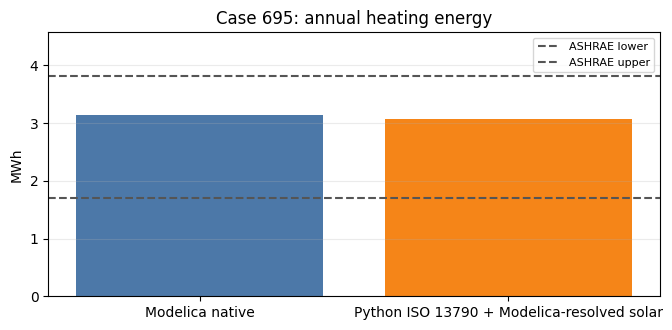

In [5]:
table=annual_energy_table(metrics, reference, case, "annual_heating_energy", ISO_MODE)
display(table)
row=table.iloc[0]; labels=["Modelica native", ISO_LABEL]; values=[row["Modelica native"],row[ISO_LABEL]]
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(labels,values,color=["#4C78A8","#F58518"])
ax.axhline(row["ASHRAE lower"],color="#555",linestyle="--",label="ASHRAE lower"); ax.axhline(row["ASHRAE upper"],color="#555",linestyle="--",label="ASHRAE upper")
ax.set(title=f"Case {case}: annual heating energy",ylabel="MWh",ylim=(0,max(values+[row["ASHRAE upper"]])*1.2)); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 5. Annual cooling figure

Annual cooling energy with published ASHRAE limits.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,695,7.49,10.58,8.755,8.974,8.386,9.172,9.149,9.039,9.323,9.265985,PASS — diagnostic


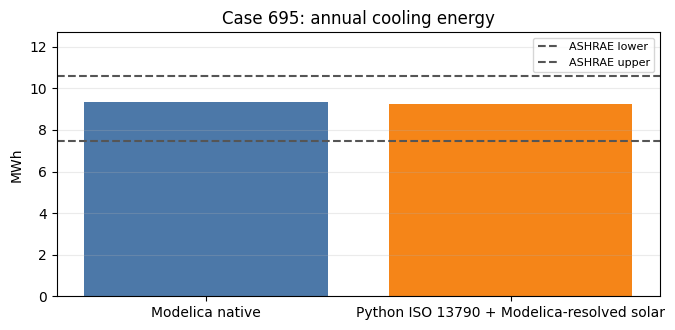

In [6]:
table=annual_energy_table(metrics, reference, case, "annual_cooling_energy", ISO_MODE)
display(table)
row=table.iloc[0]; labels=["Modelica native", ISO_LABEL]; values=[row["Modelica native"],row[ISO_LABEL]]
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(labels,values,color=["#4C78A8","#F58518"])
ax.axhline(row["ASHRAE lower"],color="#555",linestyle="--",label="ASHRAE lower"); ax.axhline(row["ASHRAE upper"],color="#555",linestyle="--",label="ASHRAE upper")
ax.set(title=f"Case {case}: annual cooling energy",ylabel="MWh",ylim=(0,max(values+[row["ASHRAE upper"]])*1.2)); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 6. Peak heating and cooling

Computed peak loads and completed-hour occurrence times.

In [7]:
display(peak_tracks(metrics,completed_hour_label))

,Track,Peak heating kW,Peak heating time,Peak cooling kW,Peak cooling time
0,Modelica native,2.271682,01-Jan:00,6.828656,22-Jan:14
1,Native ISO,2.283953,01-Jan:00,2.777800,02-Oct:17
2,ISO + Modelica solar,2.328905,01-Jan:00,6.752607,22-Jan:14


## 7. Peak-load comparison figures

Computed peak loads, kW.

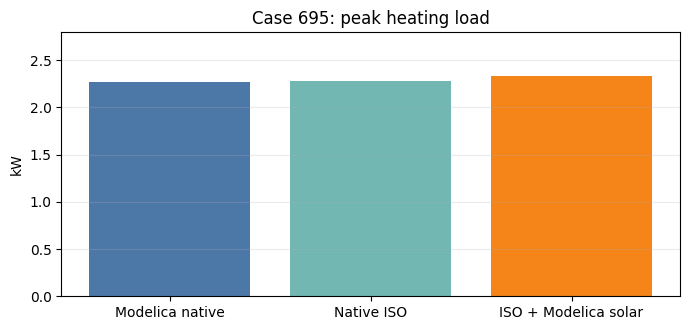

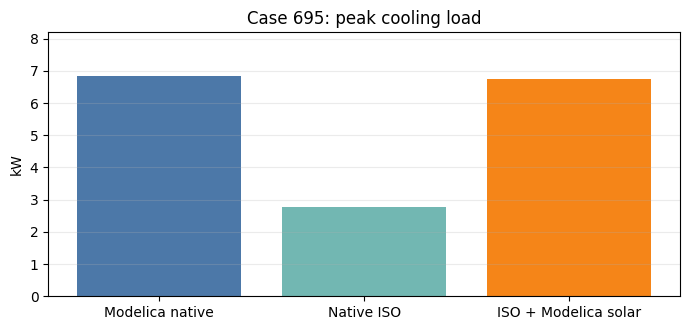

In [8]:
peaks=peak_tracks(metrics, completed_hour_label)
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(peaks["Track"],peaks["Peak heating kW"],color=["#4C78A8","#72B7B2","#F58518"])
ax.set(title=f"Case {case}: peak heating load",ylabel="kW",ylim=(0,peaks["Peak heating kW"].max()*1.2 if peaks["Peak heating kW"].max() else 1)); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()
peaks=peak_tracks(metrics, completed_hour_label)
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(peaks["Track"],peaks["Peak cooling kW"],color=["#4C78A8","#72B7B2","#F58518"])
ax.set(title=f"Case {case}: peak cooling load",ylabel="kW",ylim=(0,peaks["Peak cooling kW"].max()*1.2 if peaks["Peak cooling kW"].max() else 1)); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 8. Daily load profile

The LBNL presentation requires daily load profiles only for Cases 600 and 900; none is added for this 6XX case.

## 9. Solar forcing

Annual zone-solar totals, MWh.

In [9]:
solar_report=solar.set_index('quantity').T; solar_report['Absolute difference MWh']=(solar_report['native_rclib_zone_solar_MWh']-solar_report['modelica_resolved_zone_solar_MWh']).abs(); solar_report['Relative difference %']=(solar_report['native_modelica_ratio']-1)*100; display(solar_report.reset_index(drop=True))

quantity,native_rclib_zone_solar_MWh,modelica_resolved_zone_solar_MWh,native_modelica_ratio,Absolute difference MWh,Relative difference %
0,3.972237,11.562587,0.343542,7.59035,-65.645778


## 10. Controlled-forcing agreement

ISO + Modelica solar minus Modelica native; diagnostic only.

In [10]:
display(comparison_table(metrics,"controlled_modelica"))

,Metric,Unit,Modelica,ISO + Modelica solar,Difference,Difference %
0,Annual heating,MWh,3.146838,3.074243,-0.072595,-2.306925
1,Annual cooling,MWh,9.323000,9.265985,-0.057015,-0.611552
2,Peak heating,kW,2.271682,2.328905,0.057223,2.518960
3,Peak cooling,kW,6.828656,6.752607,-0.076049,-1.113678


## 11. Native versus controlled-forcing effect

Effect of changing only solar forcing in ISO.

In [11]:
display(comparison_table(metrics,"solar_effect").query("Metric in ['Annual heating', 'Annual cooling']"))

,Metric,Unit,Native ISO,ISO + Modelica solar,Difference,Difference %
0,Annual heating,MWh,3.613432,3.074243,-0.539189,-14.921798
1,Annual cooling,MWh,3.429614,9.265985,5.836371,170.175733


## 12. Final case outcome

Concise formal-native and controlled-forcing record.

In [12]:
judgement=range_judgement(metrics,references,case); summary=annual_tracks(metrics).set_index('Run'); summary['Formal ASHRAE status']=['; '.join(judgement['Formal status']),'diagnostic','reference implementation']; display(summary.reset_index()); print('Native ISO formal annual status:','; '.join(judgement['Formal status'])); print('Controlled forcing remains a Modelica-comparative diagnostic; no new schema or timestamp mapping is introduced.')

,Run,Heating MWh,Cooling MWh,Formal ASHRAE status
0,Native ISO,3.613432,3.429614,PASS; FAIL
1,ISO + Modelica solar,3.074243,9.265985,diagnostic
2,Modelica native,3.146838,9.323000,reference implementation


Native ISO formal annual status: PASS; FAIL
Controlled forcing remains a Modelica-comparative diagnostic; no new schema or timestamp mapping is introduced.
